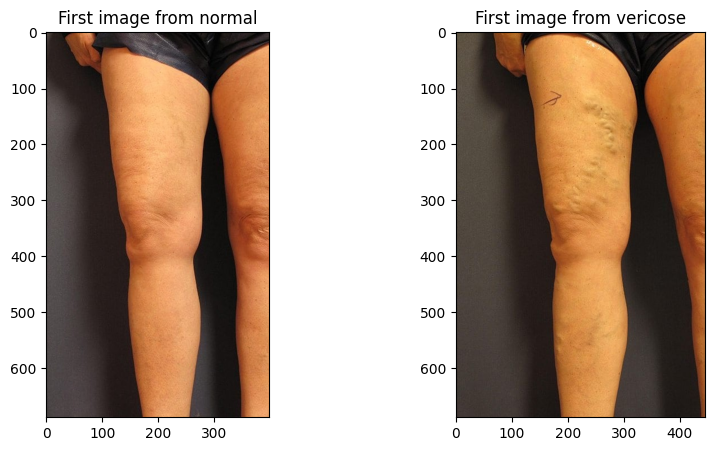

In [1]:
import cv2
import os
import matplotlib.pyplot as plt

DATADIR = r'C:\Users\Zaid Hussain\OneDrive\Desktop\Vericose project\datasetVericose\train'
CATEGORIES = ['normal', 'vericose']

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(10, 5))

for i, category in enumerate(CATEGORIES):
    path = os.path.join(DATADIR, category)
    if not os.path.exists(path):
        print(f"Directory not found: {path}")
        continue

    for img in os.listdir(path):
        if img.endswith(('.jpg', '.png')):  # Add more extensions if needed
            img_path = os.path.join(path, img)
            img_array = cv2.imread(img_path)
            if img_array is None:
                print(f"Failed to load image: {img_path}")
                continue

            # Convert color only if the image was successfully loaded
            img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"First image from {category}")
            break  # Display only the first valid image

plt.show()


In [2]:
print(img_array.shape)

(688, 445, 3)


In [3]:

def create_data(path):
    data = []
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                files = glob.glob(path+"/"+category+"/*")
                for f in files:
                    img_array = cv2.imread(f)
                    new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                    data.append([np.array(img_array), CATEGORIES.index(category)])
            except Exception as e:
                pass     
    np.random.shuffle(data)
    return data


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_data_dir = r'C:\Users\Zaid Hussain\OneDrive\Desktop\Vericose project\datasetVericose\train'
test_data_dir = r'C:\Users\Zaid Hussain\OneDrive\Desktop\Vericose project\datasetVericose\test'  # Assuming test data is in this directory



train_datagen = ImageDataGenerator(rescale=1./255, 
                             rotation_range=20,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale = 1.0/255.)

train_generator = train_datagen.flow_from_directory(train_data_dir,
                                              target_size=(224, 224), 
                                              batch_size=32,
                                              class_mode='binary')


test_generator = test_datagen.flow_from_directory(test_data_dir,
                                            target_size=(224, 224),  
                                            batch_size=32,
                                            class_mode='binary')
         

Found 118 images belonging to 2 classes.
Found 34 images belonging to 2 classes.


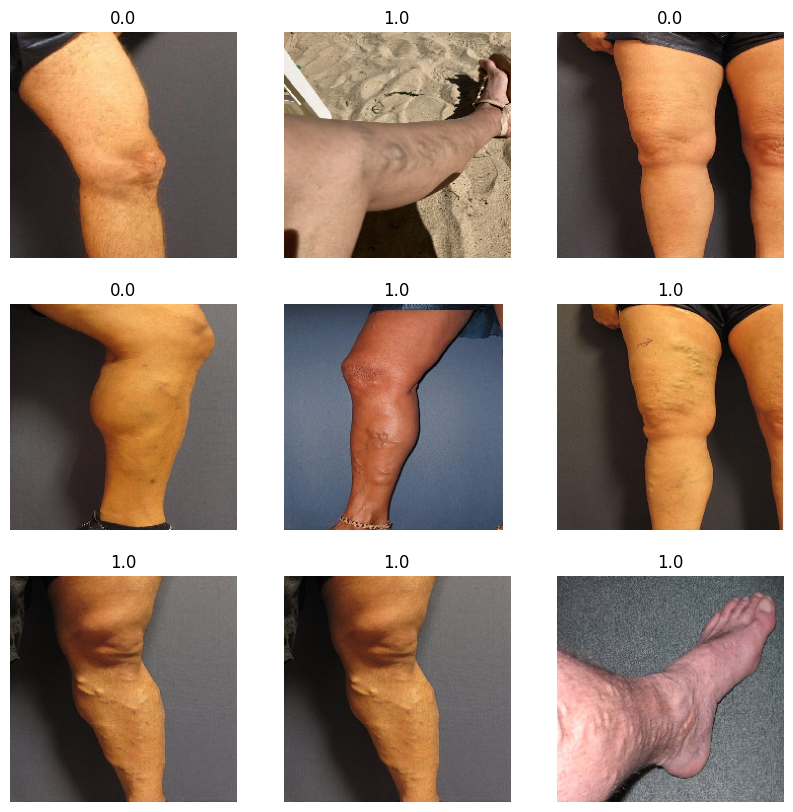

In [5]:
import matplotlib.pyplot as plt

images, labels = next(test_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(str(labels[i]) if labels[i] == 0 else str(labels[i]))
    plt.axis('off')

plt.show()

In [6]:
import tensorflow as tf
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="vericose_logs")

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# CNN model
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),  
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),  

    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])




In [8]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=test_generator,
    callbacks=[tensorboard_callback]
)
model.save(r'C:\Users\Zaid Hussain\vVeins-CNN.keras')

Epoch 1/100
4/4 [==============================] - 8s 2s/step - loss: 0.8285 - accuracy: 0.5000 - val_loss: 0.7092 - val_accuracy: 0.5000
Epoch 2/100
4/4 [==============================] - 7s 2s/step - loss: 0.7492 - accuracy: 0.5932 - val_loss: 0.7652 - val_accuracy: 0.5000
Epoch 3/100
4/4 [==============================] - 7s 2s/step - loss: 0.6951 - accuracy: 0.5678 - val_loss: 0.6920 - val_accuracy: 0.5000
Epoch 4/100
4/4 [==============================] - 7s 2s/step - loss: 0.6854 - accuracy: 0.6102 - val_loss: 0.6949 - val_accuracy: 0.5000
Epoch 5/100
4/4 [==============================] - 6s 2s/step - loss: 0.6672 - accuracy: 0.5932 - val_loss: 0.7367 - val_accuracy: 0.5000
Epoch 6/100
4/4 [==============================] - 6s 1s/step - loss: 0.6731 - accuracy: 0.5932 - val_loss: 0.6916 - val_accuracy: 0.5000
Epoch 7/100
4/4 [==============================] - 8s 2s/step - loss: 0.6674 - accuracy: 0.5932 - val_loss: 0.6862 - val_accuracy: 0.5000
Epoch 8/100
4/4 [=================

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [10]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")

2/2 [==============================] - 2s 80ms/step - loss: 0.5753 - accuracy: 0.6471
Test accuracy: 0.6470588445663452


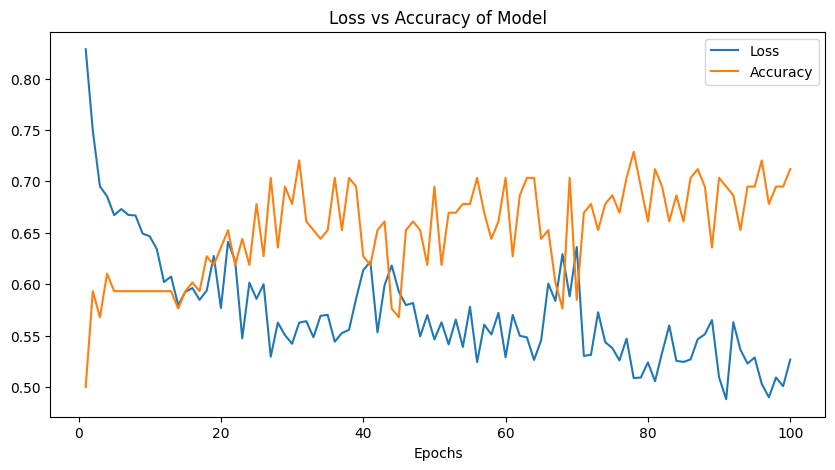

In [11]:
import matplotlib.pyplot as plt

epochs = range(1, 101) 
plt.figure(figsize=(10, 5))
plt.title("Loss vs Accuracy of Model")
plt.plot(epochs, history.history['loss'][:200], label='Loss')
plt.plot(epochs, history.history['accuracy'][:200], label='Accuracy')
plt.grid()
plt.xlabel("Epochs")
plt.grid()
plt.legend()
plt.show()


In [12]:
import numpy as np
actual = np.empty(0)
pred = np.empty(0)
for i, (test_images, true_labels) in enumerate(test_generator):
    predictions = model.predict(test_images)
    binary_predictions = [1 if pred > 0.5 else 0 for pred in predictions]
    true_labels = [int(label) for label in true_labels]
    
    for true_label, binary_prediction in zip(true_labels, binary_predictions):
        label_string = 'Normal' if true_label == 1 else 'Vericose'
        prediction_string = 'Normal' if binary_prediction == 1 else 'Vericose'
        actual = np.append(actual,[label_string])
        pred = np.append(pred,[prediction_string])
        print(f"True Label: {label_string}, Predicted Label: {prediction_string}")

    if i == len(test_generator) - 1:
        break  
print(actual)
print("\n\n\n\n")
print(pred)

1/1 [==============================] - 0s 347ms/step
True Label: Vericose, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
1/1 [==============================] - 1s 742ms/step
True Label: Normal, Predicted Label: Vericose
True Label: Normal, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Normal, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Vericose, Predicted Label: Vericose
True Label: Normal, Predicted Label: Normal
True Label: Vericose, Predicted Label: Vericose
True Label: Normal, Predicted Label: Vericose
True Label: Normal, Predicted Label: Normal
True Label: Normal, Predicted Label: Normal
True Label: Vericose, Predicted Label: Vericose
Tr

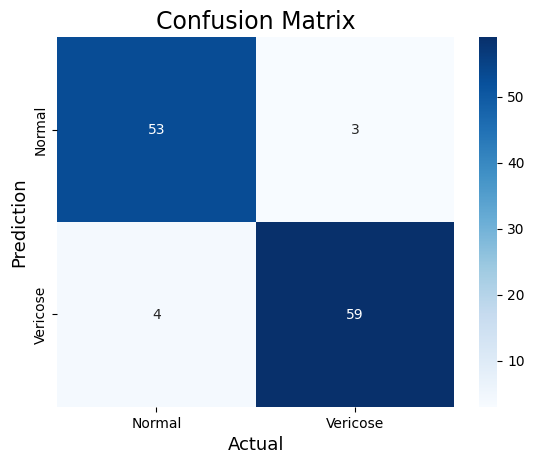

In [13]:
#Import the necessary libraries 
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt 
 
actual = np.array(
   ['Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose', 'Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal', 'Normal','Normal','Normal','Normal', 'Normal','Normal','Normal','Normal', 'Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal', 'Normal','Normal','Normal','Normal'])
pred= np.array(
    ['Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose', 'Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Vericose','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal', 'Normal','Normal','Normal','Normal', 'Normal','Normal','Normal','Normal', 'Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal','Normal', 'Normal','Vericose','Vericose','Vericose'])

cm = confusion_matrix(actual,pred)
     
#Plot the confusion matrix.  ''
sns.heatmap(cm, 
            annot=True,
           fmt='d', cmap='Blues' ,
            xticklabels=['Normal','Vericose'],
            yticklabels=['Normal','Vericose'])
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

In [14]:
from tensorflow.keras.preprocessing import image
test_image_path = r'C:\Users\Zaid Hussain\OneDrive\Desktop\Vericose project\datasetVericose\test\vericose\10.jpg'
img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  

prediction = model.predict(img_array)

binary_prediction = 1 if prediction[0] > 0.5 else 0

label_string = 'Varicose' if binary_prediction == 1 else 'Normal'
print(f"Predicted: {label_string}")


1/1 [==============================] - 0s 373ms/step
Predicted: Normal


In [1]:
from tensorflow.keras.preprocessing import image
test_image_path = r'C:\Users\Zaid Hussain\OneDrive\Desktop\Vericose project\datasetVericose\test\normal\11.jpg' 
img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  

prediction = model.predict(img_array)

binary_prediction = 1 if prediction[0] > 0.5 else 0

label_string = 'Varicose' if binary_prediction == 1 else 'Normal'
print(f"Predicted: {label_string}")

NameError: name 'np' is not defined

In [16]:
from tensorflow.keras.preprocessing import image
test_image_path = r'C:\Users\Zaid Hussain\OneDrive\Desktop\Vericose project\datasetVericose\test\normal\12.jpg' 
img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  

prediction = model.predict(img_array)

binary_prediction = 1 if prediction[0] > 0.5 else 0

label_string = 'Varicose' if binary_prediction == 1 else 'Normal'
print(f"Predicted: {label_string}")

1/1 [==============================] - 0s 111ms/step
Predicted: Normal
